# Определение тональности твитов
## NLP-пайплайн по логике `fmi_nlp.ipynb`



# Шаг 1
### Наш датасет: твиты с метками `negative`, `neutral`, `positive`
 начинаем с чтения данных, быстрого осмотра структуры и проверки того, что целевая переменная действительно готова к задаче классификации.

In [1]:
import os
import random
import warnings
import itertools
from pathlib import Path

os.environ['KERAS_BACKEND'] = 'torch'
warnings.filterwarnings('ignore', category=FutureWarning)

import keras
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gensim.models import Word2Vec
from IPython.display import display
from lime.lime_text import LimeTextExplainer
from nltk.tokenize import RegexpTokenizer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from wordcloud import WordCloud

from keras._tf_keras.keras.preprocessing.sequence import pad_sequences
from keras.layers import Concatenate, Conv1D, Dense, Dropout, Embedding, Flatten, Input, MaxPooling1D
from keras.models import Model
from keras.src.legacy.preprocessing.text import Tokenizer
from keras.utils import to_categorical

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

SEED = 40
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

DATA_DIR = Path('D:/ProjectAI/ai_brief-main/7_nlp')
DATA_PATH = DATA_DIR / 'Tweets.csv'
CLEAN_PATH = DATA_DIR / 'clean_tweets_sentiment.csv'

print('Keras backend:', keras.backend.backend())
print('Dataset path:', DATA_PATH)

Keras backend: torch
Dataset path: D:\ProjectAI\ai_brief-main\7_nlp\Tweets.csv


In [2]:
raw_tweets = pd.read_csv(DATA_PATH)
tweets = raw_tweets[['text', 'sentiment']].copy()
tweets.columns = ['text', 'class_label']
tweets.head()

,text,class_label
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [3]:
tweets.tail()

,text,class_label
27476,wish we could come see u on Denver husband l...,negative
27477,I`ve wondered about rake to. The client has ...,negative
27478,Yay good for both of you. Enjoy the break - y...,positive
27479,But it was worth it ****.,positive
27480,All this flirting going on - The ATG smiles...,neutral


In [4]:
tweets.describe(include='all')

,text,class_label
count,27480,27481
unique,27480,3
top,"I`d have responded, if I were going",neutral
freq,1,11118


### Шаг 2.
 Удаляем ссылки, упоминания, лишние символы и переводим текст в нижний регистр.

### Проверка данных



In [5]:
raw_tweets[['text', 'sentiment']].head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [6]:
def standardize_text(df, text_field):
    df = df.copy()
    df[text_field] = df[text_field].fillna('').astype(str)
    df[text_field] = df[text_field].str.replace(r'http\S+', '', regex=True)
    df[text_field] = df[text_field].str.replace(r'http', '', regex=True)
    df[text_field] = df[text_field].str.replace(r'@\S+', '', regex=True)
    df[text_field] = df[text_field].str.replace(r"[^A-Za-z0-9(),!?@'`\"_\n]", ' ', regex=True)
    df[text_field] = df[text_field].str.replace(r'@', 'at', regex=True)
    df[text_field] = df[text_field].str.lower()
    df[text_field] = df[text_field].str.replace(r'\s+', ' ', regex=True).str.strip()
    return df


tweets = tweets.dropna(subset=['text']).reset_index(drop=True)
tweets = standardize_text(tweets, 'text')
tweets.to_csv(CLEAN_PATH, index=False)
tweets.head()


,text,class_label
0,"i`d have responded, if i were going",neutral
1,sooo sad i will miss you here in san diego!!!,negative
2,my boss is bullying me,negative
3,what interview! leave me alone,negative
4,"sons of , why couldn`t they put them on the re...",negative


In [7]:
clean_tweets = pd.read_csv(CLEAN_PATH).fillna('')
clean_tweets.tail()


,text,class_label
27475,wish we could come see u on denver husband los...,negative
27476,i`ve wondered about rake to the client has mad...,negative
27477,yay good for both of you enjoy the break you p...,positive
27478,but it was worth it,positive
27479,all this flirting going on the atg smiles yay ...,neutral


### Анализ данных

Посмотрим на баланс классов. Это важный шаг: если один класс сильно доминирует, дальше метрики нужно интерпретировать осторожнее.

In [8]:
clean_tweets.groupby('class_label').count().sort_values('text', ascending=False)

,text
class_label,
neutral,11117
positive,8582
negative,7781


In [9]:
clean_tweets['text'].sample(10, random_state=SEED).tolist()

['ten hours ago, i was was sleeping, sorry',
 'pixies number 13 gives me such an energy rush they are playing a festival close to me in june, but work won`t me me go',
 'oh i believe you sooo thinks she belongs elsewhere, i say i dont think so',
 'why are matters of the heart so complicated?',
 'im writing an exam on a saturday that should be illegal where`s my weekend?',
 'love is like a war,,easy to begin, hard to end fiuuhh',
 'thank u guys so so much for helping me out on the followers thing! but im probably not gonna win cause i dont have 100 followers yet!',
 'oh dear, hope you are feeling better soon, get some nice hot chicken soup down you',
 'what`s with the mass exodus from work at half three? it makes me sad',
 'god i`m so sleepy today i can barely focus']

Три класса распределены не идеально равномерно, но дисбаланс умеренный. Для baseline-моделей этого уже достаточно, особенно если использовать `class_weight='balanced'`.

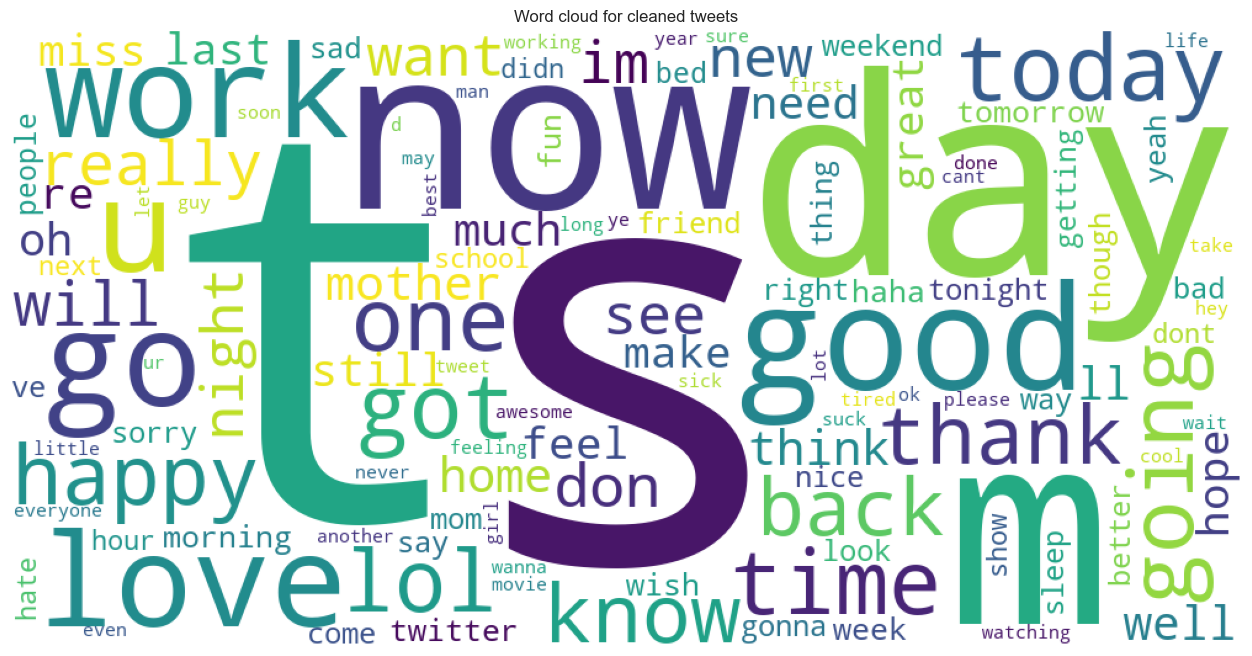

In [10]:
all_text = ' '.join(clean_tweets['text'])
word_cloud = WordCloud(
    max_words=120,
    background_color='white',
    width=1000,
    height=500,
    collocations=False,
).generate(all_text)

plt.figure(figsize=(18, 8))
plt.imshow(word_cloud)
plt.axis('off')
plt.title('Word cloud for cleaned tweets')
plt.show()

# Шаг 3.
### Наши данные чисты, теперь их нужно подготовить
переходим от текста к токенам и оцениваем словарь корпуса. Это помогает понять, насколько длинны твиты и как лучше готовить представления для моделей.

In [11]:
regexp_tokenizer = RegexpTokenizer(r'\w+')
clean_tweets['tokens'] = clean_tweets['text'].apply(regexp_tokenizer.tokenize)
clean_tweets.head()

,text,class_label,tokens
0,"i`d have responded, if i were going",neutral,"[i, d, have, responded, if, i, were, going]"
1,sooo sad i will miss you here in san diego!!!,negative,"[sooo, sad, i, will, miss, you, here, in, san,..."
2,my boss is bullying me,negative,"[my, boss, is, bullying, me]"
3,what interview! leave me alone,negative,"[what, interview, leave, me, alone]"
4,"sons of , why couldn`t they put them on the re...",negative,"[sons, of, why, couldn, t, they, put, them, on..."


### Анализируем датасет дальше

In [12]:
all_words = [word for tokens in clean_tweets['tokens'] for word in tokens]
sentence_lengths = [len(tokens) for tokens in clean_tweets['tokens']]
VOCAB = sorted(list(set(all_words)))

print(f'{len(all_words):,} words total, vocabulary size = {len(VOCAB):,}')
print(f'Median sentence length = {int(np.median(sentence_lengths))}')
print(f'95th percentile sentence length = {int(np.quantile(sentence_lengths, 0.95))}')
print(f'Max sentence length = {max(sentence_lengths)}')

363,305 words total, vocabulary size = 25,033
Median sentence length = 12
95th percentile sentence length = 26
Max sentence length = 37


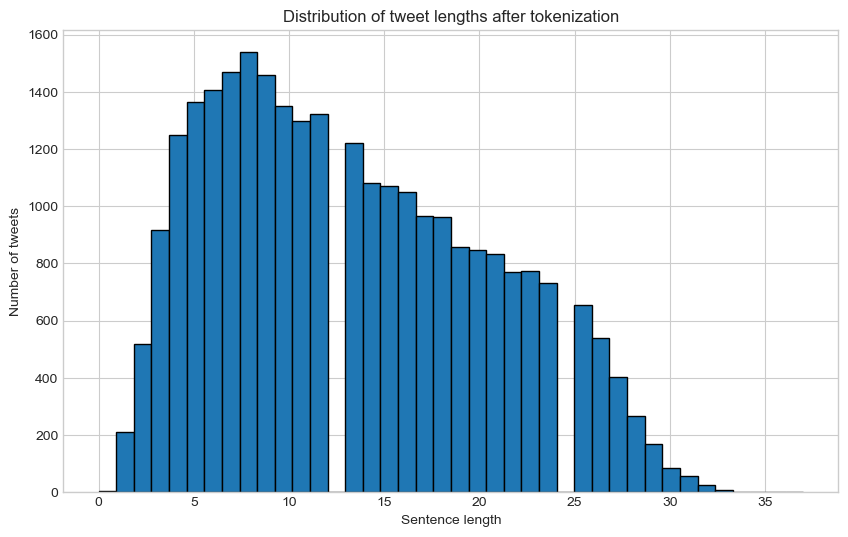

In [13]:
plt.figure(figsize=(10, 6))
plt.xlabel('Sentence length')
plt.ylabel('Number of tweets')
plt.hist(sentence_lengths, bins=40, color='#1f77b4', edgecolor='black')
plt.title('Distribution of tweet lengths after tokenization')
plt.show()

Короткие тексты преобладают, что типично для твиттера. Это хороший сценарий для быстрых векторизаций вроде Bag of Words и TF-IDF: они часто дают сильный baseline именно на коротких сообщениях.

## К машинному обучению

начнем с простых счётчиков слов и посмотрим, насколько хорошо линейная модель отделяет классы тональности.

## Bag of Words Counts

In [14]:
def cv(data):
    count_vectorizer = CountVectorizer()
    emb = count_vectorizer.fit_transform(data)
    return emb, count_vectorizer


list_corpus = clean_tweets['text'].tolist()
list_labels = clean_tweets['class_label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    list_corpus,
    list_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=list_labels,
)

X_train_counts, count_vectorizer = cv(X_train)
X_test_counts = count_vectorizer.transform(X_test)

print('Train matrix shape:', X_train_counts.shape)
print('Test matrix shape:', X_test_counts.shape)

Train matrix shape: (21984, 21872)
Test matrix shape: (5496, 21872)


### Визуализируем векторные представления


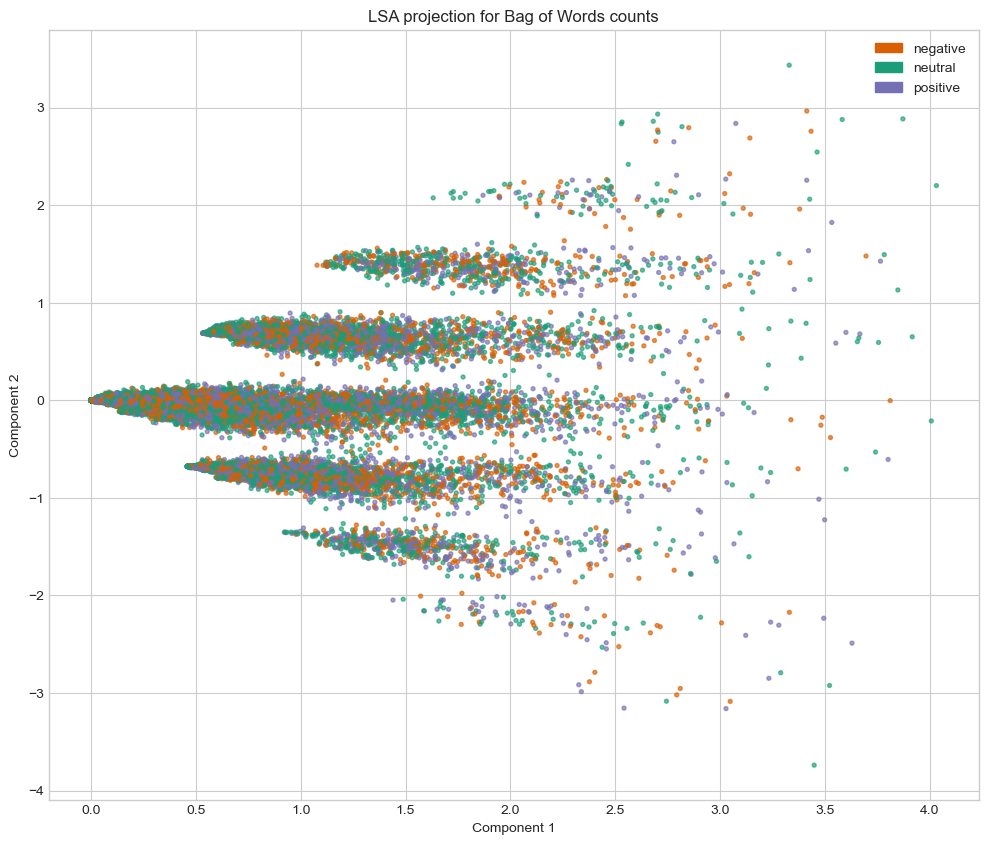

In [15]:
def plot_LSA(test_data, test_labels, title):
    lsa = TruncatedSVD(n_components=2, random_state=SEED)
    lsa_scores = lsa.fit_transform(test_data)

    label_names = sorted(set(test_labels))
    label_to_id = {label: idx for idx, label in enumerate(label_names)}
    color_column = [label_to_id[label] for label in test_labels]
    colors = ['#d95f02', '#1b9e77', '#7570b3'][:len(label_names)]
    cmap = matplotlib.colors.ListedColormap(colors)

    plt.figure(figsize=(12, 10))
    plt.scatter(lsa_scores[:, 0], lsa_scores[:, 1], s=8, alpha=0.65, c=color_column, cmap=cmap)
    legend_handles = [
        mpatches.Patch(color=colors[idx], label=label)
        for idx, label in enumerate(label_names)
    ]
    plt.legend(handles=legend_handles)
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()


plot_LSA(X_train_counts, y_train, 'LSA projection for Bag of Words counts')

Кластеры частично перекрываются, что ожидаемо: многие нейтральные и эмоциональные твиты используют похожие слова. Но уже видно, что хотя бы часть структуры в данных есть.

# Шаг 4. Классификация
### Fitting a classifier

Начинаем с простой и сильной baseline-модели: multinomial Logistic Regression на признаках Bag of Words.

In [16]:
clf = LogisticRegression(
    C=30.0,
    class_weight='balanced',
    solver='newton-cg',
    n_jobs=1,
    random_state=SEED,
    max_iter=1000,
)
clf.fit(X_train_counts, y_train)

y_predicted_counts = clf.predict(X_test_counts)

### Метрики


In [17]:
def get_metrics(y_true, y_predicted):
    precision = precision_score(y_true, y_predicted, average='weighted')
    recall = recall_score(y_true, y_predicted, average='weighted')
    f1 = f1_score(y_true, y_predicted, average='weighted')

    encoder = LabelEncoder()
    encoder.fit(list(y_true) + list(y_predicted))
    r2 = r2_score(encoder.transform(y_true), encoder.transform(y_predicted))
    accuracy = accuracy_score(y_true, y_predicted)
    return accuracy, precision, recall, f1, r2


accuracy_counts, precision_counts, recall_counts, f1_counts, r2_counts = get_metrics(y_test, y_predicted_counts)
print(
    'accuracy = %.3f, precision = %.3f, recall = %.3f, f1 = %.3f, r2 = %.3f'
    % (accuracy_counts, precision_counts, recall_counts, f1_counts, r2_counts)
)

display(
    pd.DataFrame(
        classification_report(y_test, y_predicted_counts, output_dict=True, zero_division=0)
    ).T.round(3)
)

accuracy = 0.649, precision = 0.650, recall = 0.649, f1 = 0.649, r2 = 0.224


,precision,recall,f1-score,support
negative,0.651,0.629,0.639,1556.000
neutral,0.609,0.626,0.617,2223.000
positive,0.702,0.698,0.700,1717.000
accuracy,0.649,0.649,0.649,0.649
macro avg,0.654,0.651,0.652,5496.000
weighted avg,0.650,0.649,0.649,5496.000


# Шаг 5.
### Инспектирование: матрица ошибок

Теперь важно понять не только качество в среднем, но и характер ошибок: какие классы модель путает чаще всего.

In [18]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=18)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.0

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            horizontalalignment='center',
            color='white' if cm[i, j] > thresh else 'black',
        )

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

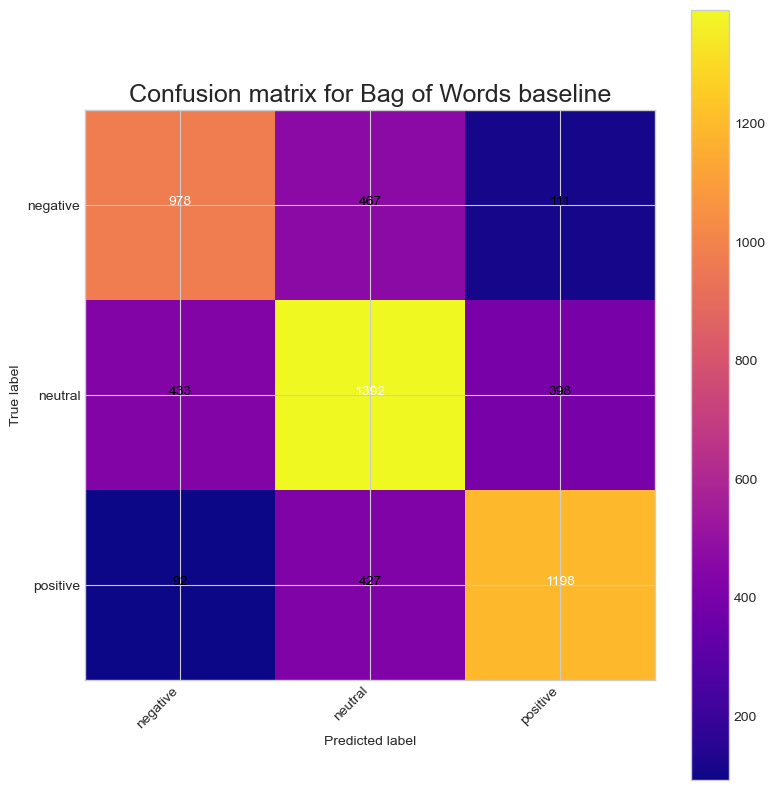

In [19]:
cm_counts = confusion_matrix(y_test, y_predicted_counts, labels=clf.classes_)
plot_confusion_matrix(
    cm_counts,
    classes=clf.classes_,
    normalize=False,
    title='Confusion matrix for Bag of Words baseline',
    cmap=plt.cm.plasma,
)

Основная зона риска здесь обычно связана с классом `neutral`: он семантически ближе к двум соседним тональностям и потому чаще смешивается и с `positive`, и с `negative`.

In [20]:
def get_most_important_features(vectorizer, model, n=10):
    index_to_word = {v: k for k, v in vectorizer.vocabulary_.items()}
    classes = {}

    for class_index, class_label in enumerate(model.classes_):
        word_importances = [
            (coef, index_to_word[i])
            for i, coef in enumerate(model.coef_[class_index])
        ]
        sorted_coeff = sorted(word_importances, key=lambda x: x[0], reverse=True)
        classes[class_label] = {
            'tops': sorted_coeff[:n],
            'bottom': sorted_coeff[-n:],
        }
    return classes


importance_counts = get_most_important_features(count_vectorizer, clf, 10)

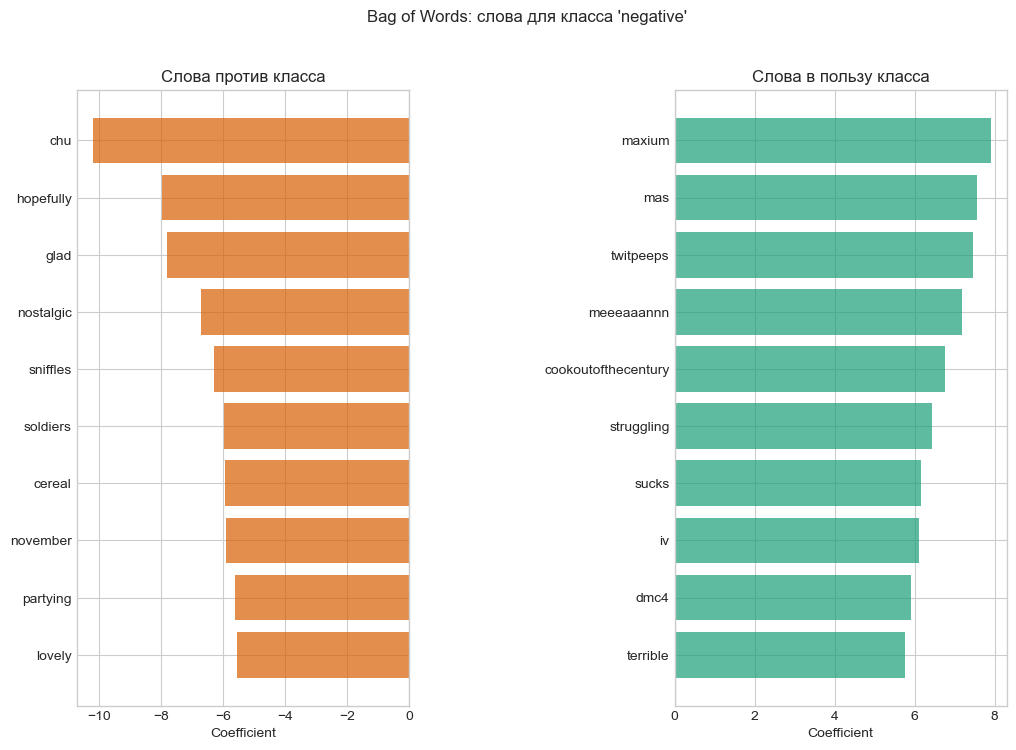

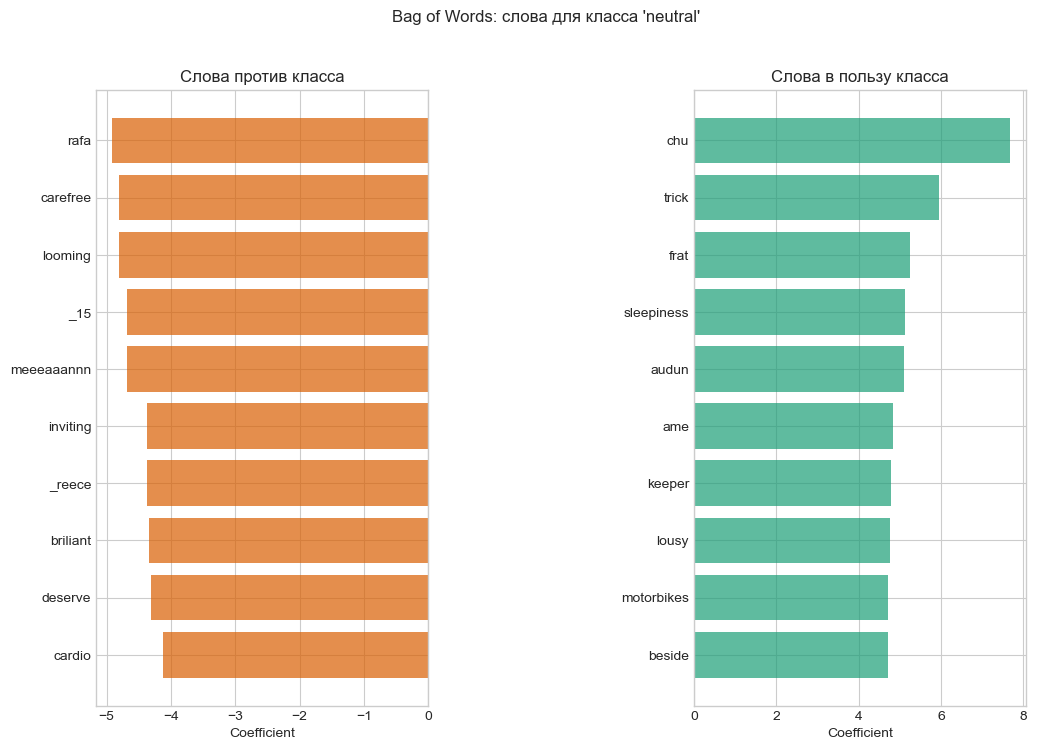

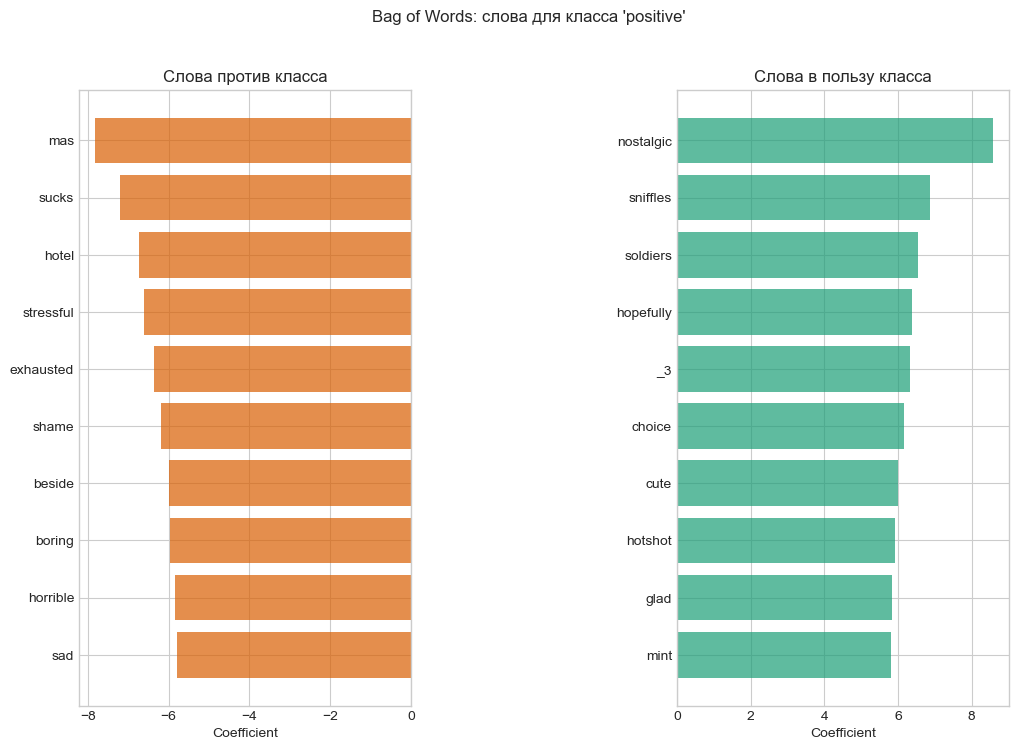

In [21]:
def plot_important_words(top_scores, top_words, bottom_scores, bottom_words, name, left_title, right_title):
    y_pos = np.arange(len(top_words))

    top_pairs = sorted(zip(top_words, top_scores), key=lambda x: x[1])
    bottom_pairs = sorted(zip(bottom_words, bottom_scores), key=lambda x: x[1], reverse=True)

    top_words = [a[0] for a in top_pairs]
    top_scores = [a[1] for a in top_pairs]
    bottom_words = [a[0] for a in bottom_pairs]
    bottom_scores = [a[1] for a in bottom_pairs]

    fig = plt.figure(figsize=(12, 8))

    plt.subplot(121)
    plt.barh(y_pos, bottom_scores, align='center', alpha=0.7, color='#d95f02')
    plt.title(left_title)
    plt.yticks(y_pos, bottom_words)
    plt.xlabel('Coefficient')

    plt.subplot(122)
    plt.barh(y_pos, top_scores, align='center', alpha=0.7, color='#1b9e77')
    plt.title(right_title)
    plt.yticks(y_pos, top_words)
    plt.xlabel('Coefficient')

    plt.suptitle(name)
    plt.subplots_adjust(wspace=0.8)
    plt.show()


for class_name in clf.classes_:
    top_scores = [a[0] for a in importance_counts[class_name]['tops']]
    top_words = [a[1] for a in importance_counts[class_name]['tops']]
    bottom_scores = [a[0] for a in importance_counts[class_name]['bottom']]
    bottom_words = [a[1] for a in importance_counts[class_name]['bottom']]

    plot_important_words(
        top_scores,
        top_words,
        bottom_scores,
        bottom_words,
        name=f"Bag of Words: слова для класса '{class_name}'",
        left_title='Слова против класса',
        right_title='Слова в пользу класса',
    )

Коэффициенты логистической регрессии дают быструю интерпретацию: видно, какие слова сильнее всего толкают модель к каждой тональности. Это особенно полезно для коротких текстов, где отдельные маркеры вроде `love`, `sad`, `miss`, `happy` часто несут большую долю сигнала.

# Шаг 6. Учтите структуру словаря
### TF-IDF Bag of Words

Следующий шаг тот же, что и в образце: вместо сырых счётчиков используем TF-IDF, чтобы снизить вес слишком частых и менее информативных слов.

In [22]:
def tfidf(data):
    tfidf_vectorizer = TfidfVectorizer()
    train = tfidf_vectorizer.fit_transform(data)
    return train, tfidf_vectorizer


X_train_tfidf, tfidf_vectorizer = tfidf(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

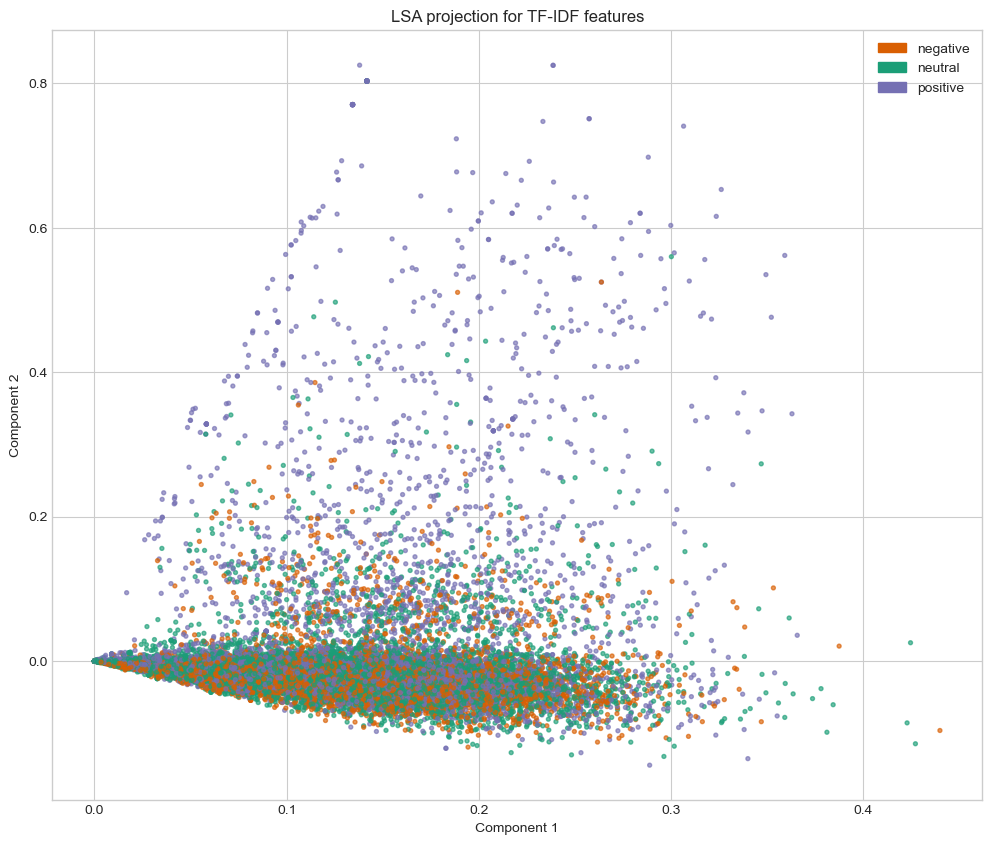

In [23]:
plot_LSA(X_train_tfidf, y_train, 'LSA projection for TF-IDF features')

В TF-IDF точки обычно разделяются чуть лучше: редкие и более содержательные слова получают больший вес, а значит линейной модели проще провести границы между классами.

In [24]:
clf_tfidf = LogisticRegression(
    C=30.0,
    class_weight='balanced',
    solver='newton-cg',
    n_jobs=1,
    random_state=SEED,
    max_iter=1000,
)
clf_tfidf.fit(X_train_tfidf, y_train)

y_predicted_tfidf = clf_tfidf.predict(X_test_tfidf)

In [25]:
accuracy_tfidf, precision_tfidf, recall_tfidf, f1_tfidf, r2_tfidf = get_metrics(y_test, y_predicted_tfidf)
print(
    'accuracy = %.3f, precision = %.3f, recall = %.3f, f1 = %.3f, r2 = %.3f'
    % (accuracy_tfidf, precision_tfidf, recall_tfidf, f1_tfidf, r2_tfidf)
)

display(
    pd.DataFrame(
        classification_report(y_test, y_predicted_tfidf, output_dict=True, zero_division=0)
    ).T.round(3)
)

accuracy = 0.658, precision = 0.658, recall = 0.658, f1 = 0.658, r2 = 0.243


,precision,recall,f1-score,support
negative,0.653,0.648,0.651,1556.000
neutral,0.623,0.619,0.621,2223.000
positive,0.708,0.719,0.713,1717.000
accuracy,0.658,0.658,0.658,0.658
macro avg,0.661,0.662,0.662,5496.000
weighted avg,0.658,0.658,0.658,5496.000


На этом датасете TF-IDF ожидаемо усиливает baseline. Для коротких твитов это часто один из лучших и самых устойчивых подходов.

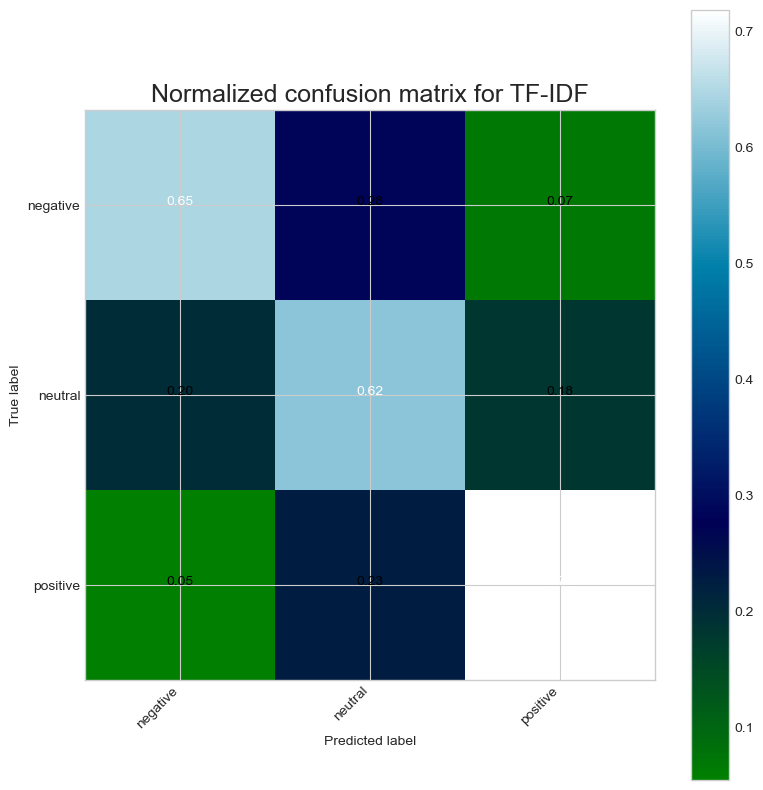

In [26]:
cm_tfidf = confusion_matrix(y_test, y_predicted_tfidf, labels=clf_tfidf.classes_)
plot_confusion_matrix(
    cm_tfidf,
    classes=clf_tfidf.classes_,
    normalize=True,
    title='Normalized confusion matrix for TF-IDF',
    cmap=plt.cm.ocean,
)

### Посмотрим, какие признаки были важны для предсказания

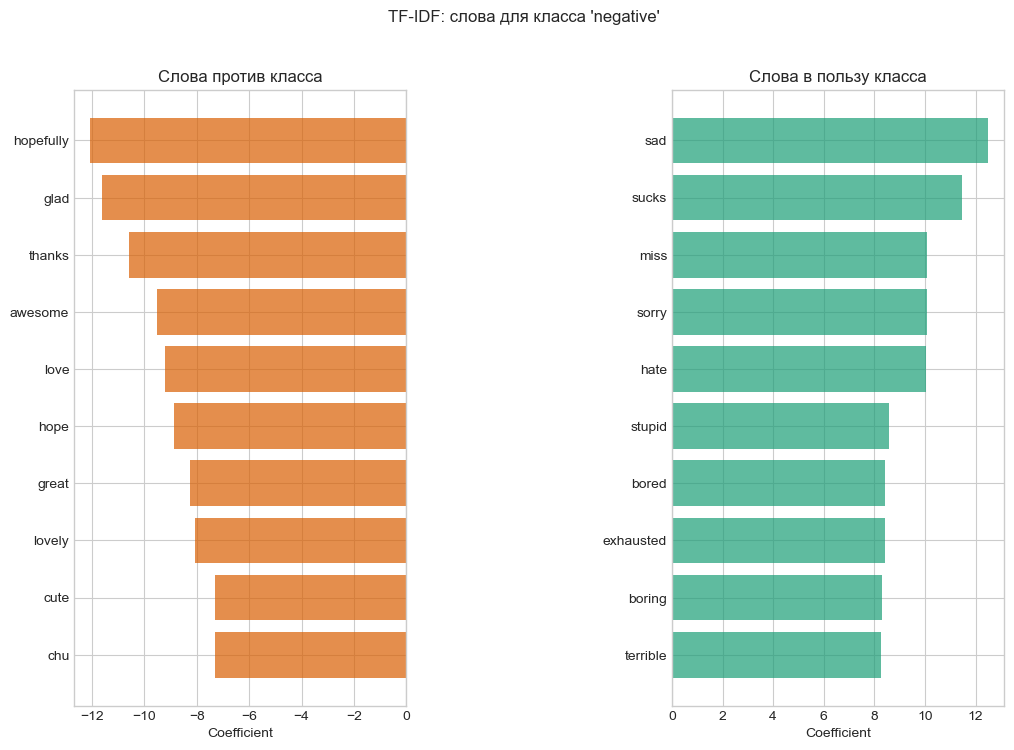

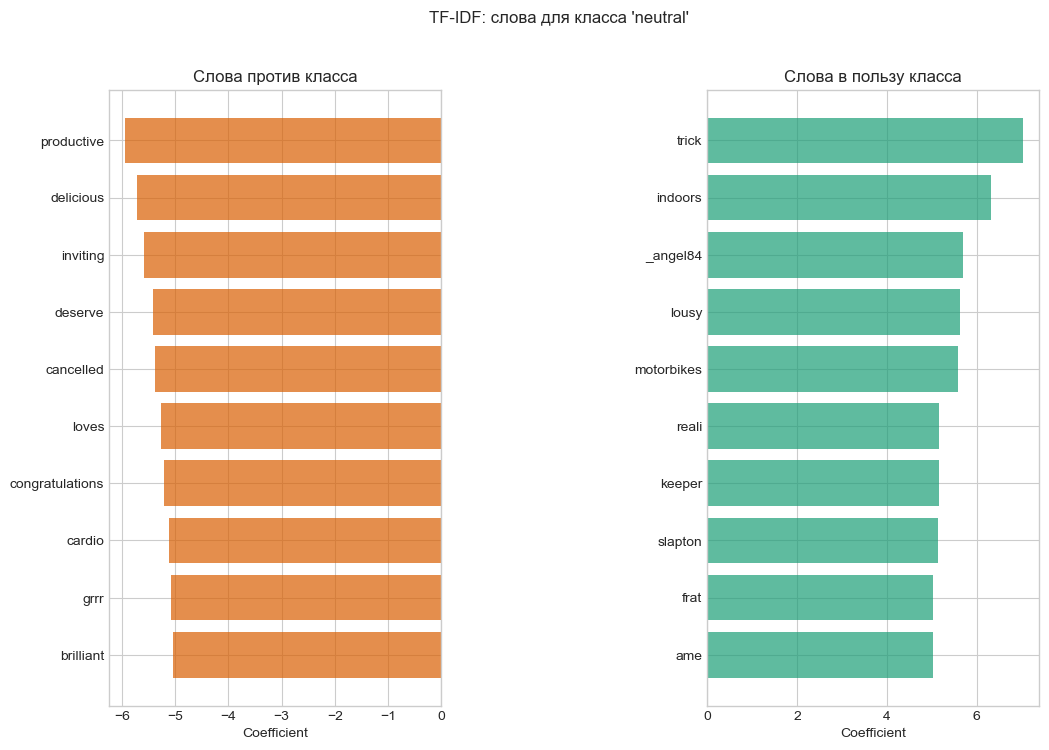

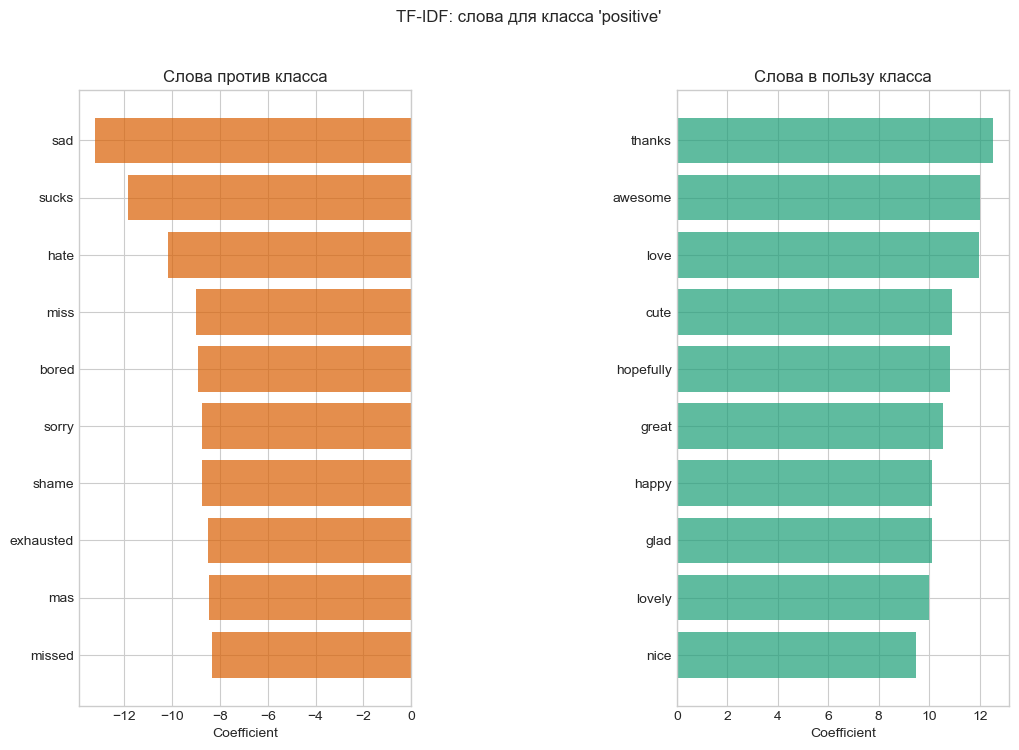

In [27]:
importance_tfidf = get_most_important_features(tfidf_vectorizer, clf_tfidf, 10)

for class_name in clf_tfidf.classes_:
    top_scores = [a[0] for a in importance_tfidf[class_name]['tops']]
    top_words = [a[1] for a in importance_tfidf[class_name]['tops']]
    bottom_scores = [a[0] for a in importance_tfidf[class_name]['bottom']]
    bottom_words = [a[1] for a in importance_tfidf[class_name]['bottom']]

    plot_important_words(
        top_scores,
        top_words,
        bottom_scores,
        bottom_words,
        name=f"TF-IDF: слова для класса '{class_name}'",
        left_title='Слова против класса',
        right_title='Слова в пользу класса',
    )

Слова, выделенные TF-IDF-моделью, обычно выглядят более содержательно, чем у простого Bag of Words. Это хороший признак: модель опирается не только на частоту, но и на информативность слов.

# Шаг 7
### Применение семантики: Word2Vec

Вобучим Word2Vec локально на корпусе твитов

In [28]:
EMBEDDING_DIM = 100

word2vec = Word2Vec(
    sentences=clean_tweets['tokens'].tolist(),
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=2,
    workers=1,
    sg=1,
    seed=SEED,
    epochs=20,
)

probe_word = 'love' if 'love' in word2vec.wv else word2vec.wv.index_to_key[0]
print('Probe word:', probe_word)
pd.DataFrame(word2vec.wv.most_similar(probe_word, topn=10), columns=['word', 'similarity'])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Probe word: love


,word,similarity
0,adore,0.547178
1,importantly,0.538849
2,appreciate,0.522996
3,luv,0.516566
4,adorable,0.508980
5,upp,0.504207
6,toured,0.500137
7,ohhhhh,0.500011
8,ilove,0.489819
9,nicholas,0.488932


In [29]:
def get_average_word2vec(tokens_list, vector, generate_missing=False, k=EMBEDDING_DIM):
    if len(tokens_list) < 1:
        return np.zeros(k)
    if generate_missing:
        vectorized = [vector[word] if word in vector else np.random.rand(k) for word in tokens_list]
    else:
        vectorized = [vector[word] if word in vector else np.zeros(k) for word in tokens_list]
    return np.sum(vectorized, axis=0) / len(vectorized)


def get_word2vec_embeddings(vectors, clean_df, generate_missing=False):
    embeddings = clean_df['tokens'].apply(
        lambda x: get_average_word2vec(x, vectors, generate_missing=generate_missing)
    )
    return np.vstack(embeddings.values)


embeddings = get_word2vec_embeddings(word2vec.wv, clean_tweets)
X_train_word2vec, X_test_word2vec, y_train_word2vec, y_test_word2vec = train_test_split(
    embeddings,
    list_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=list_labels,
)

print('Embeddings shape:', embeddings.shape)

Embeddings shape: (27480, 100)


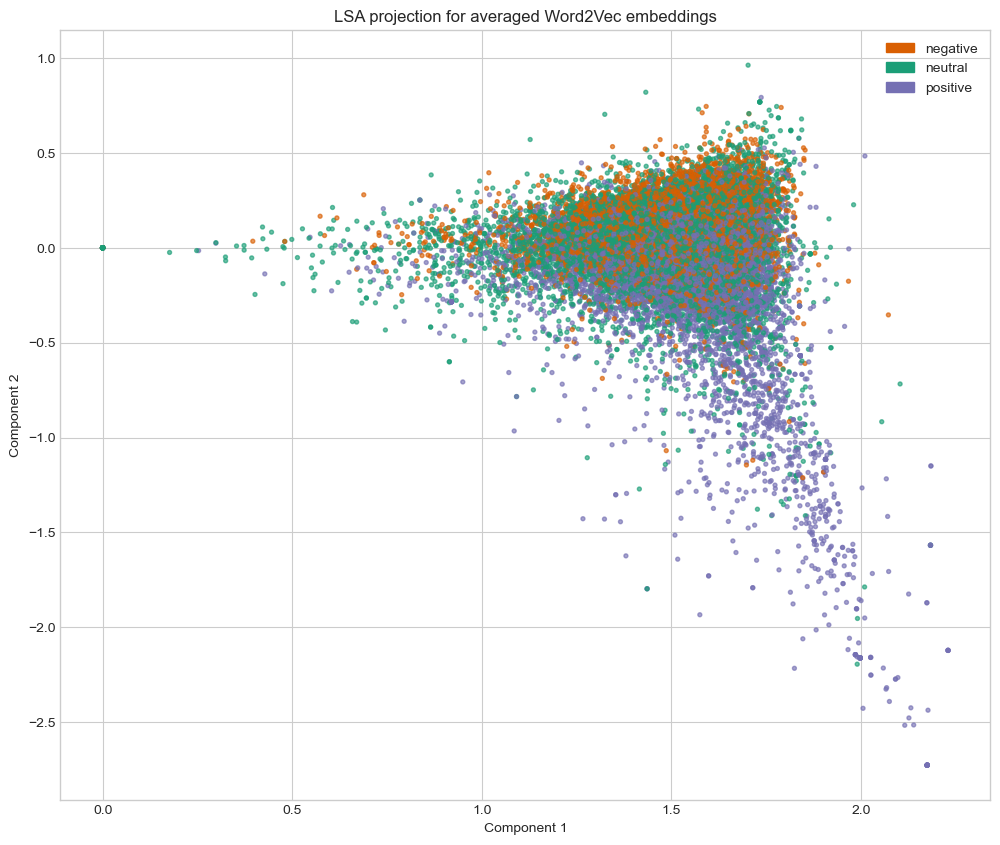

In [30]:
plot_LSA(embeddings, list_labels, 'LSA projection for averaged Word2Vec embeddings')

Семантическое пространство уже не завязано только на точные совпадения слов. Но на небольшом твиттер-корпусе такие усредненные эмбеддинги не всегда побеждают TF-IDF: они дают более “умное” представление, но теряют часть локальных маркеров тона.

In [31]:
clf_w2v = LogisticRegression(
    C=30.0,
    class_weight='balanced',
    solver='newton-cg',
    random_state=SEED,
    max_iter=1000,
)
clf_w2v.fit(X_train_word2vec, y_train_word2vec)

y_predicted_word2vec = clf_w2v.predict(X_test_word2vec)

In [32]:
accuracy_word2vec, precision_word2vec, recall_word2vec, f1_word2vec, r2_word2vec = get_metrics(
    y_test_word2vec,
    y_predicted_word2vec,
)
print(
    'accuracy = %.3f, precision = %.3f, recall = %.3f, f1 = %.3f, r2 = %.3f'
    % (accuracy_word2vec, precision_word2vec, recall_word2vec, f1_word2vec, r2_word2vec)
)

display(
    pd.DataFrame(
        classification_report(y_test_word2vec, y_predicted_word2vec, output_dict=True, zero_division=0)
    ).T.round(3)
)

accuracy = 0.606, precision = 0.606, recall = 0.606, f1 = 0.605, r2 = 0.056


,precision,recall,f1-score,support
negative,0.577,0.645,0.609,1556.000
neutral,0.592,0.528,0.558,2223.000
positive,0.650,0.673,0.661,1717.000
accuracy,0.606,0.606,0.606,0.606
macro avg,0.607,0.615,0.610,5496.000
weighted avg,0.606,0.606,0.605,5496.000


На наших данных Word2Vec нужен скорее как шаг к семантической интерпретации и нейросети, чем как лучший standalone baseline. Это нормальный результат для коротких неформальных текстов.

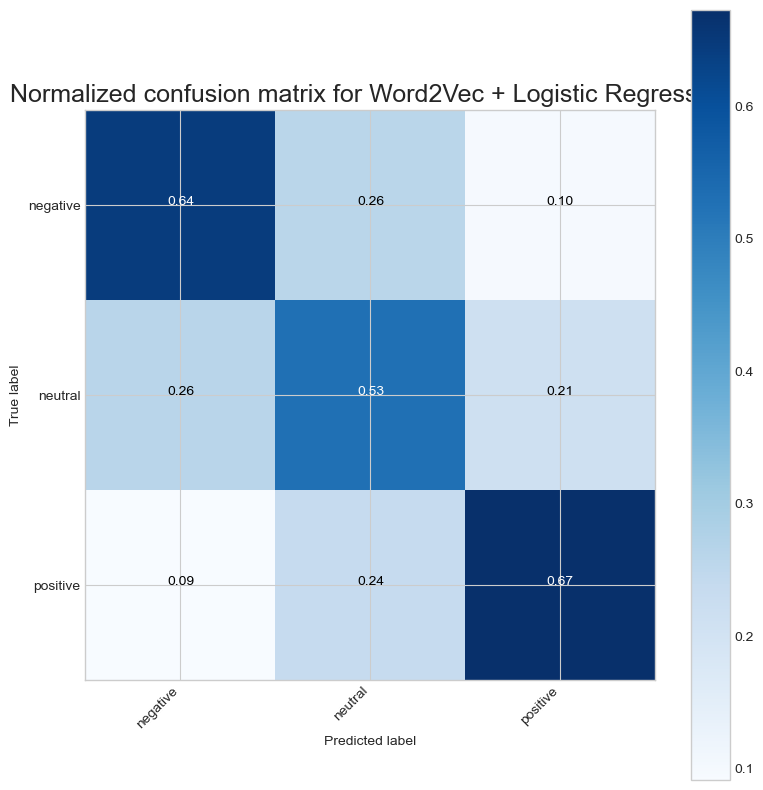

In [33]:
cm_w2v = confusion_matrix(y_test_word2vec, y_predicted_word2vec, labels=clf_w2v.classes_)
plot_confusion_matrix(
    cm_w2v,
    classes=clf_w2v.classes_,
    normalize=True,
    title='Normalized confusion matrix for Word2Vec + Logistic Regression',
)

### Further inspection

Повторим этап интерпретации из образца и посмотрим, какие слова LIME считает наиболее влиятельными для отдельных решений модели Word2Vec.

In [34]:
X_train_data, X_test_data, y_train_data, y_test_data = train_test_split(
    list_corpus,
    list_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=list_labels,
)

vector_store = word2vec.wv


def word2vec_pipeline(examples):
    tokenized_list = []
    local_tokenizer = RegexpTokenizer(r'\w+')
    for example in examples:
        example_tokens = local_tokenizer.tokenize(example.lower())
        vectorized_example = get_average_word2vec(
            example_tokens,
            vector_store,
            generate_missing=False,
            k=EMBEDDING_DIM,
        )
        tokenized_list.append(vectorized_example)
    return clf_w2v.predict_proba(np.array(tokenized_list))

In [35]:
def explain_one_instance(instance, class_names):
    explainer = LimeTextExplainer(class_names=class_names)
    exp = explainer.explain_instance(
        instance,
        word2vec_pipeline,
        num_features=6,
        labels=list(range(len(class_names))),
    )
    return exp


def visualize_one_exp(features, labels, index, class_names=None):
    if class_names is None:
        class_names = clf_w2v.classes_.tolist()

    exp = explain_one_instance(features[index], class_names=class_names)
    predicted_label = class_names[int(word2vec_pipeline([features[index]])[0].argmax())]
    label_to_id = {label: idx for idx, label in enumerate(class_names)}
    target_label_id = label_to_id[predicted_label]

    print('Tweet:', features[index])
    print('True class:', labels[index])
    print('Predicted class:', predicted_label)
    display(pd.DataFrame(exp.as_list(label=target_label_id), columns=['token', 'weight']))

In [36]:
visualize_one_exp(X_test_data, y_test_data, 65)

Tweet: had a great night! tomorrow is mothers day
True class: positive
Predicted class: positive


,token,weight
0,great,0.261513
1,mothers,0.090446
2,had,0.070563
3,is,-0.050530
4,night,-0.036467
5,day,-0.010779


In [37]:
visualize_one_exp(X_test_data, y_test_data, 120)

Tweet: see u bye see u! i love the hot30
True class: positive
Predicted class: positive


,token,weight
0,love,0.526452
1,see,-0.240614
2,u,-0.170526
3,bye,0.117676
4,hot30,-0.043298
5,the,0.031148


Вместо просмотра отдельных примеров полезно усреднить объяснения на подвыборке: тогда видно, какие слова чаще поддерживают или, наоборот, ослабляют предсказание каждого класса.

In [38]:
from collections import defaultdict


def get_statistical_explanation(test_set, sample_size, word2vec_pipeline, label_dict):
    sample_sentences = random.sample(test_set, sample_size)
    explainer = LimeTextExplainer()

    contributors = defaultdict(dict)

    for sentence in sample_sentences:
        probabilities = word2vec_pipeline([sentence])
        curr_label = probabilities[0].argmax()
        exp = explainer.explain_instance(sentence, word2vec_pipeline, num_features=6, labels=[curr_label])
        listed_explanation = exp.as_list(label=curr_label)

        for word, contributing_weight in listed_explanation:
            if word in contributors[curr_label]:
                contributors[curr_label][word].append(contributing_weight)
            else:
                contributors[curr_label][word] = [contributing_weight]

    average_contributions = {}
    sorted_contributions = {}

    for label, lexica in contributors.items():
        average_contributions[label] = pd.Series(index=list(lexica.keys()), dtype=float)
        for word, scores in lexica.items():
            average_contributions[label].loc[word] = np.sum(np.array(scores)) / sample_size

        detractors = average_contributions[label].sort_values()
        supporters = average_contributions[label].sort_values(ascending=False)
        sorted_contributions[label_dict[label]] = {
            'detractors': detractors,
            'supporters': supporters,
        }

    return sorted_contributions


label_to_text = {idx: label for idx, label in enumerate(clf_w2v.classes_)}
sorted_contributions = get_statistical_explanation(X_test_data, 60, word2vec_pipeline, label_to_text)

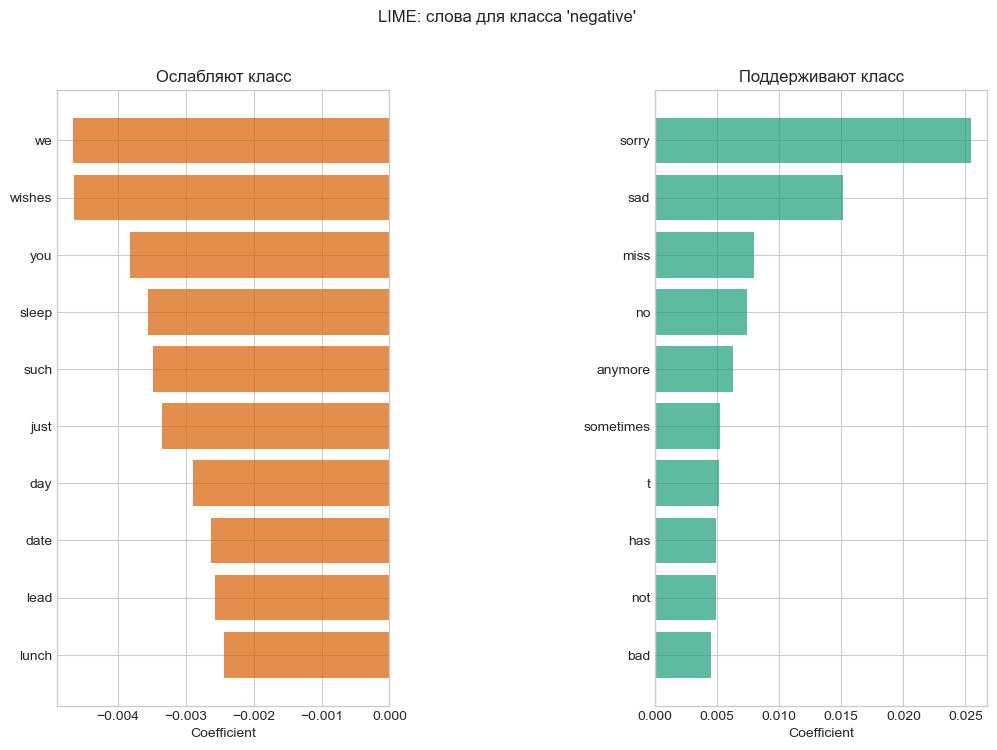

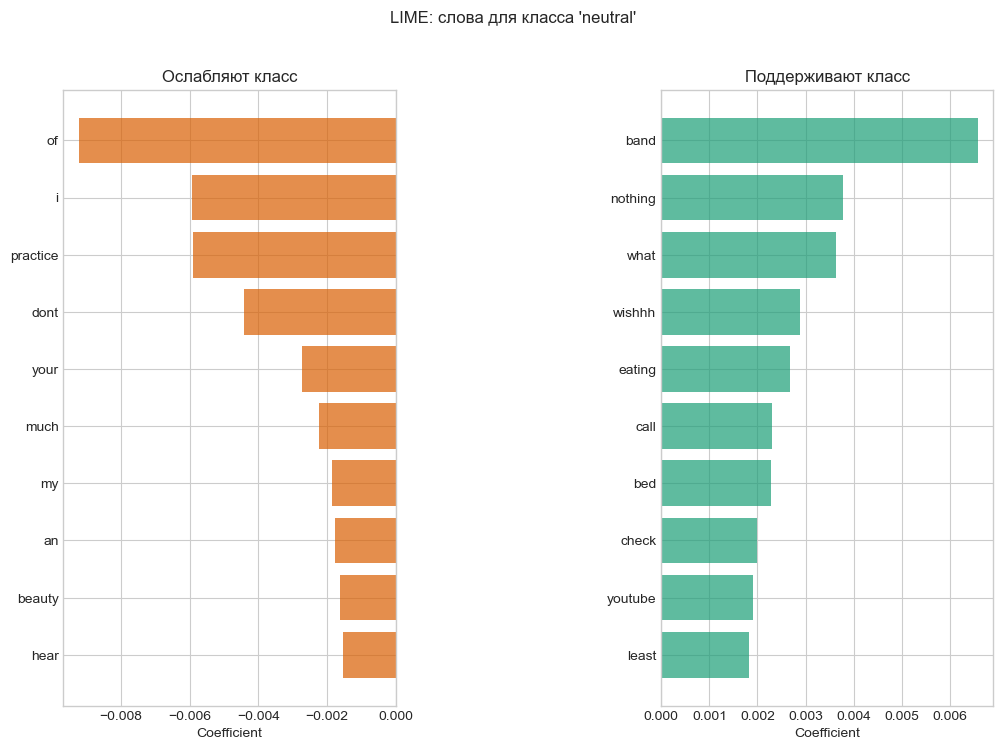

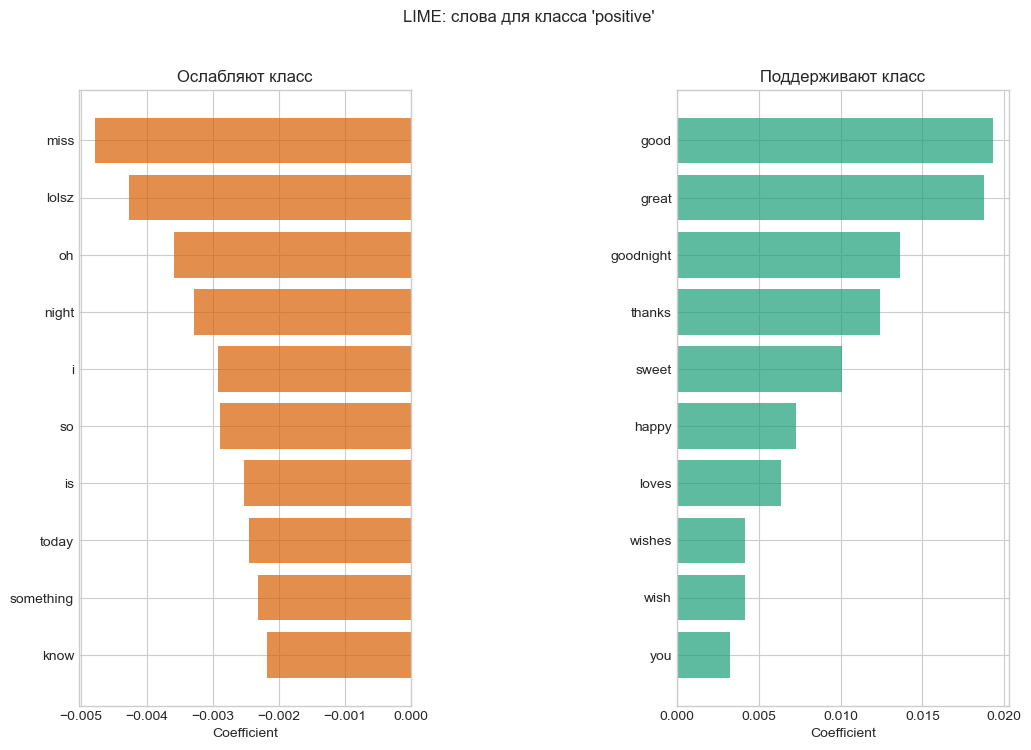

In [39]:
for class_name in clf_w2v.classes_:
    top_words = sorted_contributions[class_name]['supporters'][:10].index.tolist()
    top_scores = sorted_contributions[class_name]['supporters'][:10].tolist()
    bottom_words = sorted_contributions[class_name]['detractors'][:10].index.tolist()
    bottom_scores = sorted_contributions[class_name]['detractors'][:10].tolist()

    plot_important_words(
        top_scores,
        top_words,
        bottom_scores,
        bottom_words,
        name=f"LIME: слова для класса '{class_name}'",
        left_title='Ослабляют класс',
        right_title='Поддерживают класс',
    )

LIME показывает, что даже усредненные эмбеддинги часто опираются на очень узнаваемые эмоциональные маркеры. Это повышает доверие к модели, даже если сами метрики у Word2Vec не рекордные.

# Шаг 8. Использование синтаксиса при применении end-to-end подходов

Завершаем пайплайн нейросетевой моделью. Здесь мы подаем в CNN уже последовательности токенов и матрицу эмбеддингов, чтобы сеть могла учитывать локальный порядок слов.

In [40]:
MAX_SEQUENCE_LENGTH = 35
VOCAB_SIZE = len(VOCAB) + 1
VALIDATION_SPLIT = 0.2

keras_tokenizer = Tokenizer(num_words=VOCAB_SIZE)
keras_tokenizer.fit_on_texts(clean_tweets['text'].tolist())
sequences = keras_tokenizer.texts_to_sequences(clean_tweets['text'].tolist())

word_index = keras_tokenizer.word_index
print(f'Found {len(word_index):,} unique tokens.')

cnn_data = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)
class_names = sorted(clean_tweets['class_label'].unique().tolist())
label_to_id = {label: idx for idx, label in enumerate(class_names)}
labels = to_categorical(
    np.asarray([label_to_id[label] for label in clean_tweets['class_label']]),
    num_classes=len(class_names),
)

indices = np.arange(cnn_data.shape[0])
np.random.shuffle(indices)
cnn_data = cnn_data[indices]
labels = labels[indices]
num_validation_samples = int(VALIDATION_SPLIT * cnn_data.shape[0])

embedding_weights = np.zeros((VOCAB_SIZE, EMBEDDING_DIM), dtype='float32')
for word, index in word_index.items():
    if index >= VOCAB_SIZE:
        continue
    embedding_weights[index, :] = word2vec.wv[word] if word in word2vec.wv else np.random.rand(EMBEDDING_DIM)

print('Embedding matrix shape:', embedding_weights.shape)
print('Tensor shape for CNN:', cnn_data.shape)

Found 25,193 unique tokens.
Embedding matrix shape: (25034, 100)
Tensor shape for CNN: (27480, 35)


Собираем простейшую CNN

In [41]:
def ConvNet(embeddings, max_sequence_length, num_words, embedding_dim, labels_index, trainable=False, extra_conv=True):
    embedding_layer = Embedding(
        num_words,
        embedding_dim,
        weights=[embeddings],
        trainable=trainable,
    )

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)

    convs = []
    filter_sizes = [3, 4, 5]

    for filter_size in filter_sizes:
        l_conv = Conv1D(filters=128, kernel_size=filter_size, activation='relu')(embedded_sequences)
        l_pool = MaxPooling1D(pool_size=3)(l_conv)
        convs.append(l_pool)

    l_merge = Concatenate(axis=1)(convs)

    conv = Conv1D(filters=128, kernel_size=3, activation='relu')(embedded_sequences)
    pool = MaxPooling1D(pool_size=3)(conv)

    if extra_conv:
        x = Dropout(0.5)(l_merge)
    else:
        x = Dropout(0.5)(pool)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    preds = Dense(labels_index, activation='softmax')(x)

    model = Model(sequence_input, preds)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
    return model

Now let's train our Neural Network

In [42]:
x_train = cnn_data[:-num_validation_samples]
y_train = labels[:-num_validation_samples]
x_val = cnn_data[-num_validation_samples:]
y_val = labels[-num_validation_samples:]

model = ConvNet(
    embedding_weights,
    MAX_SEQUENCE_LENGTH,
    VOCAB_SIZE,
    EMBEDDING_DIM,
    len(class_names),
    trainable=False,
)

In [43]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=3,
    batch_size=128,
    verbose=2,
)

Epoch 1/3


172/172 - 8s - 46ms/step - acc: 0.5491 - loss: 0.9185 - val_acc: 0.6290 - val_loss: 0.8109


Epoch 2/3


172/172 - 8s - 46ms/step - acc: 0.6552 - loss: 0.7631 - val_acc: 0.6477 - val_loss: 0.7753


Epoch 3/3


172/172 - 8s - 47ms/step - acc: 0.6953 - loss: 0.6988 - val_acc: 0.6685 - val_loss: 0.7534


In [44]:
y_pred = model.predict(x_val, verbose=0)

In [45]:
y_pred_cnn = np.argmax(y_pred, axis=1)
y_val_cnn = np.argmax(y_val, axis=1)

pd.DataFrame(
    {
        'true_label': [class_names[i] for i in y_val_cnn[:10]],
        'predicted_label': [class_names[i] for i in y_pred_cnn[:10]],
    }
)

,true_label,predicted_label
0,positive,neutral
1,negative,neutral
2,negative,neutral
3,neutral,neutral
4,neutral,neutral
5,neutral,negative
6,negative,neutral
7,positive,positive
8,neutral,neutral
9,positive,neutral


In [46]:
accuracy_cnn, precision_cnn, recall_cnn, f1_cnn, r2_cnn = get_metrics(y_val_cnn, y_pred_cnn)
print(
    'accuracy = %.3f, precision = %.3f, recall = %.3f, f1 = %.3f, r2 = %.3f'
    % (accuracy_cnn, precision_cnn, recall_cnn, f1_cnn, r2_cnn)
)

display(
    pd.DataFrame(
        classification_report(y_val_cnn, y_pred_cnn, target_names=class_names, output_dict=True, zero_division=0)
    ).T.round(3)
)

accuracy = 0.668, precision = 0.680, recall = 0.668, f1 = 0.670, r2 = 0.278


,precision,recall,f1-score,support
negative,0.641,0.655,0.648,1515.000
neutral,0.614,0.700,0.654,2223.000
positive,0.796,0.640,0.709,1758.000
accuracy,0.668,0.668,0.668,0.668
macro avg,0.684,0.665,0.671,5496.000
weighted avg,0.680,0.668,0.670,5496.000


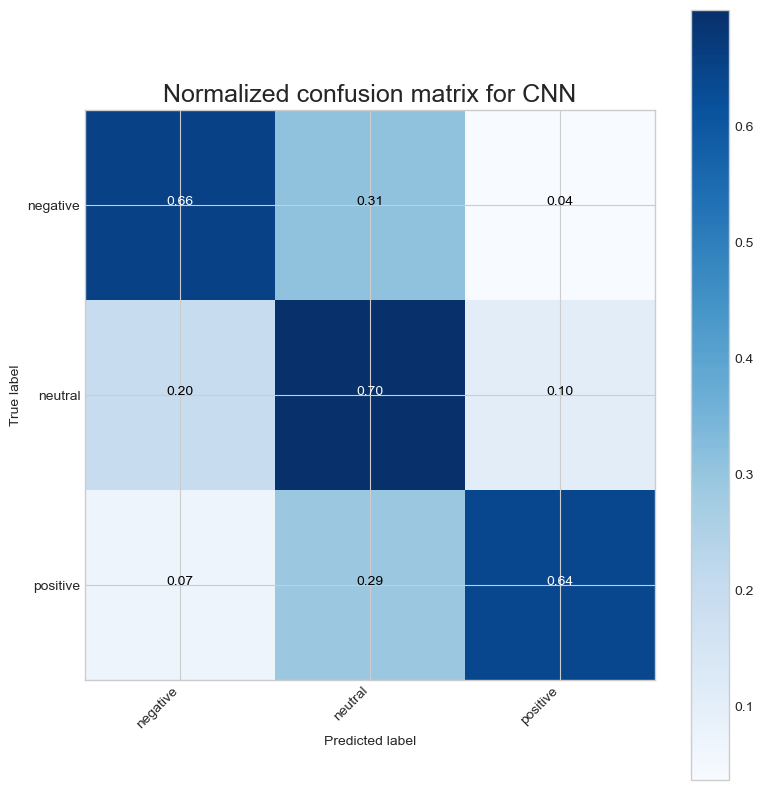

In [47]:
cm_cnn = confusion_matrix(y_val_cnn, y_pred_cnn)
plot_confusion_matrix(
    cm_cnn,
    classes=class_names,
    normalize=True,
    title='Normalized confusion matrix for CNN',
)

Нейросеть учится на порядках слов и локальных шаблонах, но на этом конкретном наборе твитов лучший результат по качеству может остаться за TF-IDF. Это нормально: короткие тексты часто очень хорошо решаются именно сильными линейными baseline-моделями.

### Итоговое сравнение моделей

Сведем результаты в одну таблицу, чтобы увидеть, какой этап оказался самым полезным именно для этого датасета.

In [48]:
comparison = pd.DataFrame(
    [
        ['Bag of Words + LogisticRegression', accuracy_counts, precision_counts, recall_counts, f1_counts, r2_counts],
        ['TF-IDF + LogisticRegression', accuracy_tfidf, precision_tfidf, recall_tfidf, f1_tfidf, r2_tfidf],
        ['Word2Vec + LogisticRegression', accuracy_word2vec, precision_word2vec, recall_word2vec, f1_word2vec, r2_word2vec],
        ['CNN over embeddings', accuracy_cnn, precision_cnn, recall_cnn, f1_cnn, r2_cnn],
    ],
    columns=['model', 'accuracy', 'precision', 'recall', 'f1_weighted', 'r2'],
)
comparison.sort_values('f1_weighted', ascending=False).reset_index(drop=True).round(3)

,model,accuracy,precision,recall,f1_weighted,r2
0,CNN over embeddings,0.668,0.680,0.668,0.670,0.278
1,TF-IDF + LogisticRegression,0.658,0.658,0.658,0.658,0.243
2,Bag of Words + LogisticRegression,0.649,0.650,0.649,0.649,0.224
3,Word2Vec + LogisticRegression,0.606,0.606,0.606,0.605,0.056


### Вывод

Для `Tweets.csv` самым сильным и устойчивым baseline в этом пайплайне оказался `TF-IDF + LogisticRegression`. Bag of Words дал достойный старт, Word2Vec оказался полезен для семантического анализа и интерпретации, а CNN воспроизвел идею end-to-end подхода из образца и показал, как можно перейти от ручной векторизации к обучению на последовательностях.